# 🍷 Classificação de Qualidade de Vinhos com Machine Learning
**Tech Challenge - Fase 2 | POSTECH DTAT**

---
**Dataset:** [Wine Quality Dataset](https://www.kaggle.com/datasets/yasserh/wine-quality-dataset) (Kaggle) — `WineQT.csv`, 1.143 amostras de vinho tinto
**Objetivo:** Classificar vinhos como Alta Qualidade (nota ≥ 7) ou Baixa/Média Qualidade (nota < 7)
**Modelos:** Random Forest vs Logistic Regression

## 0. Imports e Configurações

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay, f1_score, accuracy_score,
    precision_score, recall_score
)
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

# Diretório de saída (gráficos e métricas)
RESULTS_DIR = '../results'
os.makedirs(RESULTS_DIR, exist_ok=True)

# Reprodutibilidade
SEED = 42
np.random.seed(SEED)

# Estilo dos gráficos
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='muted')

print('✅ Bibliotecas importadas com sucesso!')

✅ Bibliotecas importadas com sucesso!


---
## 1. Compreensão do Problema

A avaliação sensorial de vinhos é subjetiva e depende de especialistas. O objetivo deste projeto é construir um modelo preditivo capaz de classificar a qualidade de um vinho com base em características físico-químicas mensuráveis.

**Variável alvo (target):** `quality_binary`
- `1` → Alta Qualidade (nota original ≥ 7)
- `0` → Baixa/Média Qualidade (nota original < 7)

---
## 2. Carregamento dos Dados

In [2]:
# Carrega o dataset (Wine Quality Dataset — Kaggle)
# Fonte: https://www.kaggle.com/datasets/yasserh/wine-quality-dataset
# Arquivo: WineQT.csv — 1.143 amostras de vinho TINTO, 11 variáveis
# físico-químicas + a nota de qualidade atribuída por especialistas.
DATA_PATH = '../data/WineQT.csv'

df = pd.read_csv(DATA_PATH)

# 'Id' é apenas o identificador da amostra: não é uma variável preditiva.
df = df.drop(columns=['Id'])
df.columns = df.columns.str.replace(' ', '_')

print(f'Shape do dataset: {df.shape}')
print(f'Amostras: {len(df)}  |  Variáveis físico-químicas: {df.shape[1] - 1}')
df.head()

Shape do dataset: (1143, 12)
Amostras: 1143  |  Variáveis físico-químicas: 11


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
# Informações gerais
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         1143 non-null   float64
 1   volatile_acidity      1143 non-null   float64
 2   citric_acid           1143 non-null   float64
 3   residual_sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free_sulfur_dioxide   1143 non-null   float64
 6   total_sulfur_dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 107.3 KB


In [4]:
# Estatísticas descritivas
df.describe().round(3)

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,1143.000,1143.000,1143.000,1143.000,1143.000,1143.000,1143.000,1143.000,1143.000,1143.000,1143.000,1143.000
mean,8.311,0.531,0.268,2.532,0.087,15.615,45.915,0.997,3.311,0.658,10.442,5.657
std,1.748,0.180,0.197,1.356,0.047,10.250,32.782,0.002,0.157,0.170,1.082,0.806
min,4.600,0.120,0.000,0.900,0.012,1.000,6.000,0.990,2.740,0.330,8.400,3.000
25%,7.100,0.392,0.090,1.900,0.070,7.000,21.000,0.996,3.205,0.550,9.500,5.000
50%,7.900,0.520,0.250,2.200,0.079,13.000,37.000,0.997,3.310,0.620,10.200,6.000
75%,9.100,0.640,0.420,2.600,0.090,21.000,61.000,0.998,3.400,0.730,11.100,6.000
max,15.900,1.580,1.000,15.500,0.611,68.000,289.000,1.004,4.010,2.000,14.900,8.000


---
## 3. Análise Exploratória de Dados (EDA)

In [5]:
# 3.1 Dados faltantes
missing = df.isnull().sum()
print('Valores faltantes por coluna:')
print(missing[missing > 0] if missing.sum() > 0 else '✅ Nenhum valor faltante encontrado!')

Valores faltantes por coluna:
✅ Nenhum valor faltante encontrado!


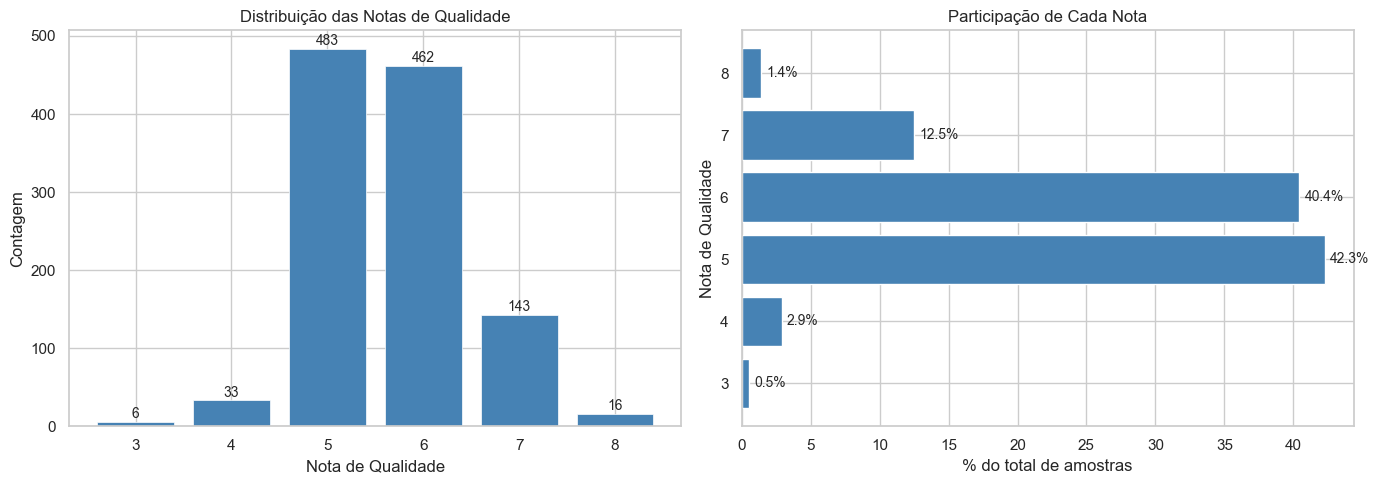


As notas se concentram em 5 e 6 (83% das amostras).
Os extremos são raros: nota 3 tem 6 amostras e nota 8 tem 16.
Não existem notas 9 ou 10 nesta base — a melhor nota observada é 8.


In [6]:
# 3.2 Distribuição da variável quality (original)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

quality_counts = df['quality'].value_counts().sort_index()
axes[0].bar(quality_counts.index, quality_counts.values, color='steelblue',
            edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Nota de Qualidade')
axes[0].set_ylabel('Contagem')
axes[0].set_title('Distribuição das Notas de Qualidade')
for x, v in zip(quality_counts.index, quality_counts.values):
    axes[0].text(x, v + 5, str(v), ha='center', fontsize=10)

# Participação de cada nota no total
axes[1].barh(quality_counts.index.astype(str), quality_counts.values / len(df) * 100,
             color='steelblue', edgecolor='white')
axes[1].set_xlabel('% do total de amostras')
axes[1].set_ylabel('Nota de Qualidade')
axes[1].set_title('Participação de Cada Nota')
for y, v in enumerate(quality_counts.values / len(df) * 100):
    axes[1].text(v + 0.4, y, f'{v:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/01_distribuicao_qualidade.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nAs notas se concentram em 5 e 6 (83% das amostras).')
print('Os extremos são raros: nota 3 tem 6 amostras e nota 8 tem 16.')
print('Não existem notas 9 ou 10 nesta base — a melhor nota observada é 8.')

Distribuição das classes:
  Baixa/Média Qualidade (<7): 984 amostras (86.1%)
  Alta Qualidade (≥7): 159 amostras (13.9%)


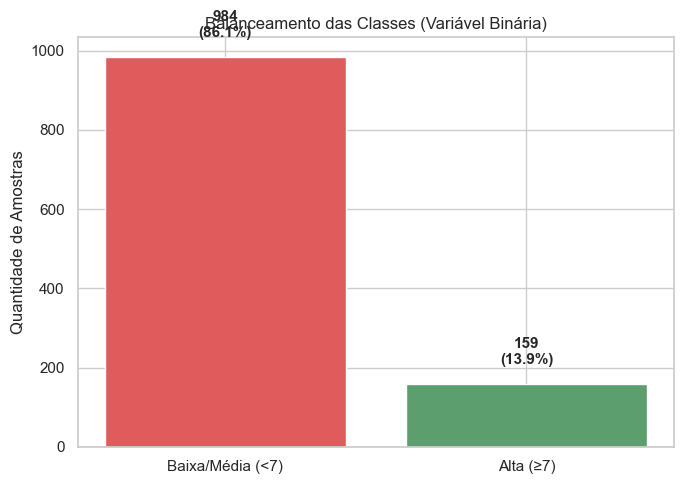


Razão de desbalanceamento: 6.19:1 → Dataset moderadamente desbalanceado.


In [7]:
# 3.3 Criação da variável binária (Target)
df['quality_binary'] = (df['quality'] >= 7).astype(int)

# Balanceamento das classes
class_dist = df['quality_binary'].value_counts()
pct = df['quality_binary'].value_counts(normalize=True) * 100

print('Distribuição das classes:')
for cls, cnt in class_dist.items():
    label = 'Alta Qualidade (≥7)' if cls == 1 else 'Baixa/Média Qualidade (<7)'
    print(f'  {label}: {cnt} amostras ({pct[cls]:.1f}%)')

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(['Baixa/Média (<7)', 'Alta (≥7)'], class_dist.sort_index().values,
              color=['#E05C5C', '#5C9E6E'], edgecolor='white')
for bar, val in zip(bars, class_dist.sort_index().values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
            f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Balanceamento das Classes (Variável Binária)')
ax.set_ylabel('Quantidade de Amostras')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/02_balanceamento_classes.png', dpi=150, bbox_inches='tight')
plt.show()

ratio = class_dist.max() / class_dist.min()
print(f'\nRazão de desbalanceamento: {ratio:.2f}:1 → Dataset moderadamente desbalanceado.')

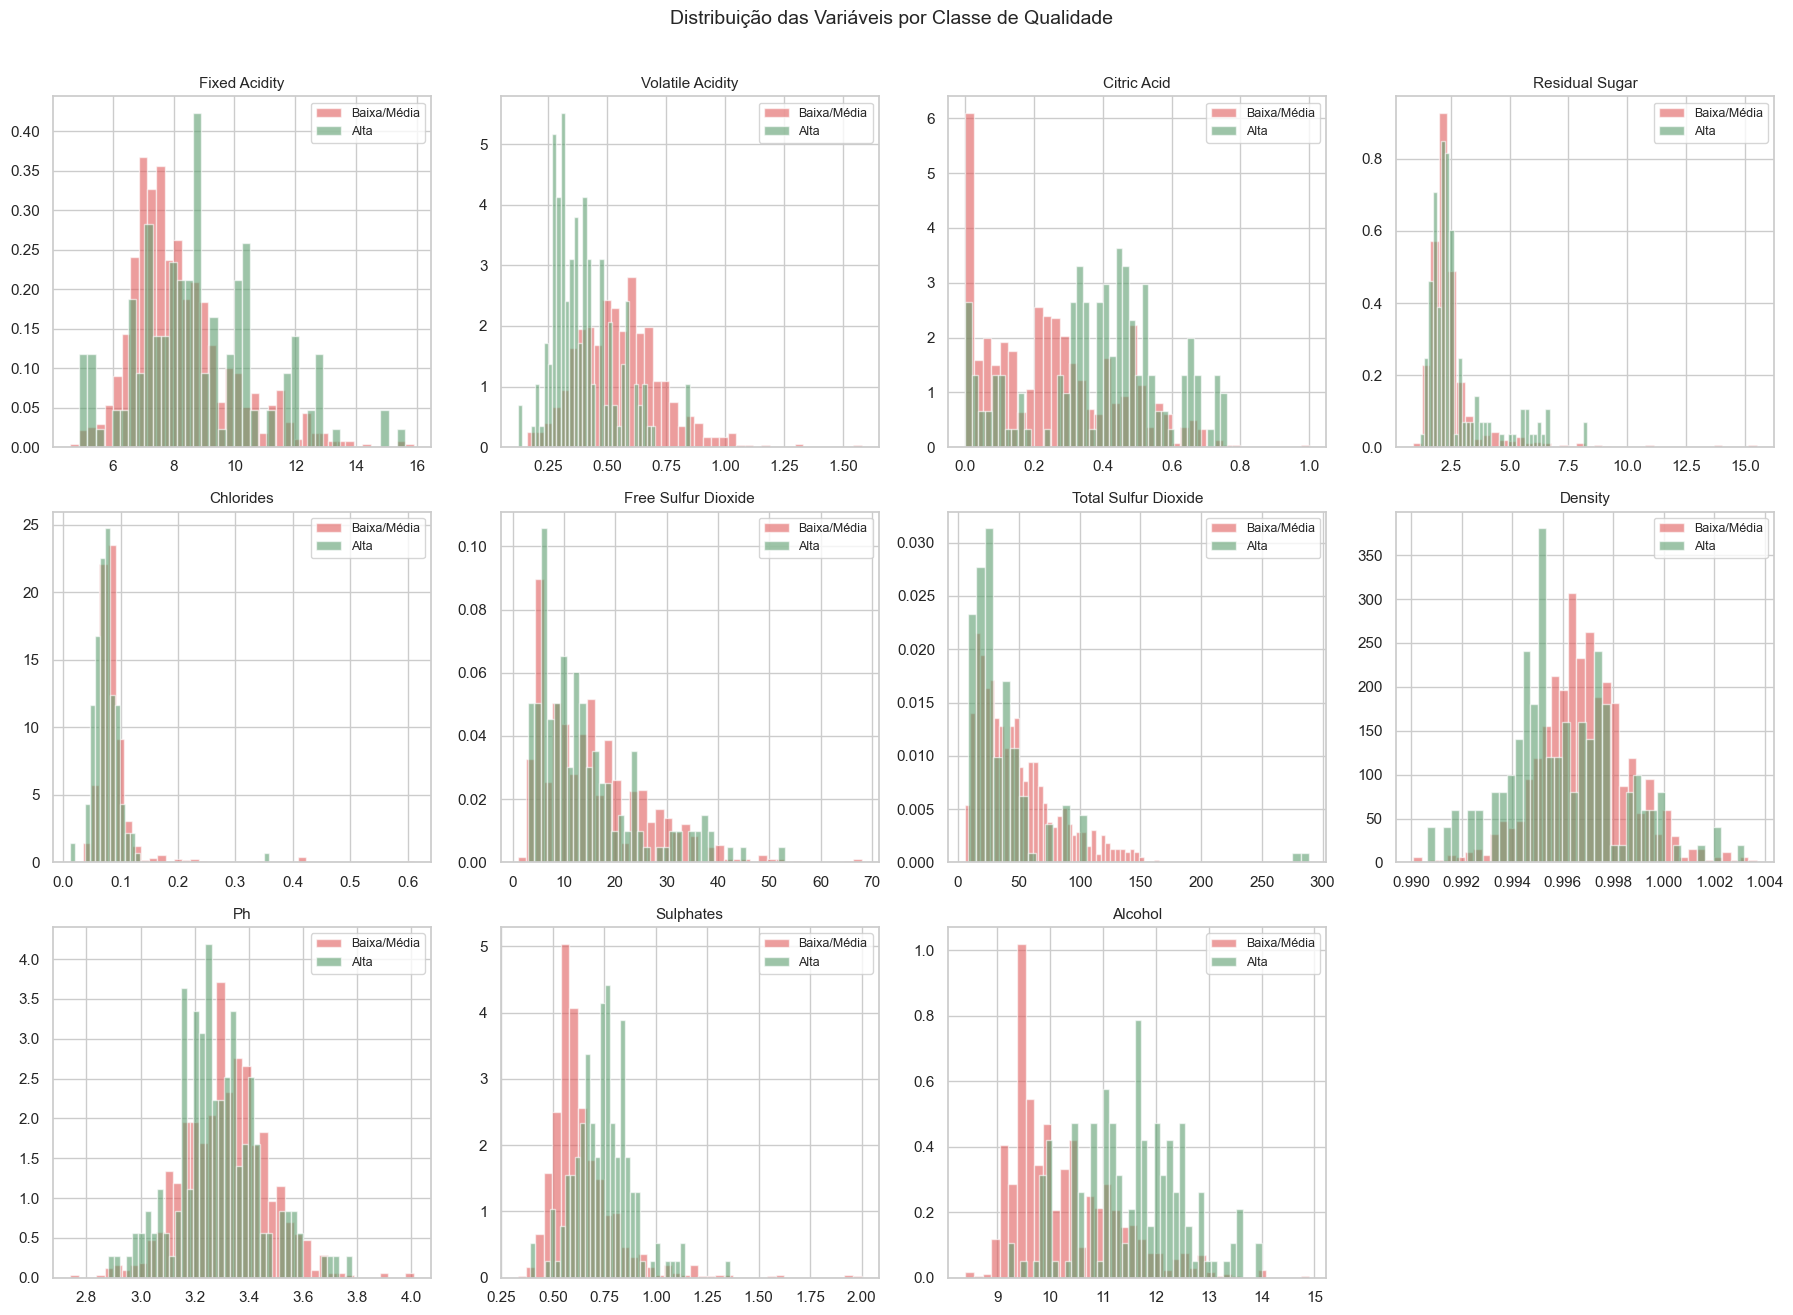

In [8]:
# 3.4 Distribuição das variáveis numéricas
num_cols = [c for c in df.columns if c not in ['quality', 'quality_binary']]

fig, axes = plt.subplots(3, 4, figsize=(18, 13))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for cls, color, label in [(0, '#E05C5C', 'Baixa/Média'), (1, '#5C9E6E', 'Alta')]:
        axes[i].hist(df[df['quality_binary'] == cls][col], bins=40, alpha=0.6,
                     color=color, label=label, density=True)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=11)
    axes[i].legend(fontsize=9)

# Remove eixos sobrando
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuição das Variáveis por Classe de Qualidade', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/03_distribuicao_variaveis.png', dpi=150, bbox_inches='tight')
plt.show()

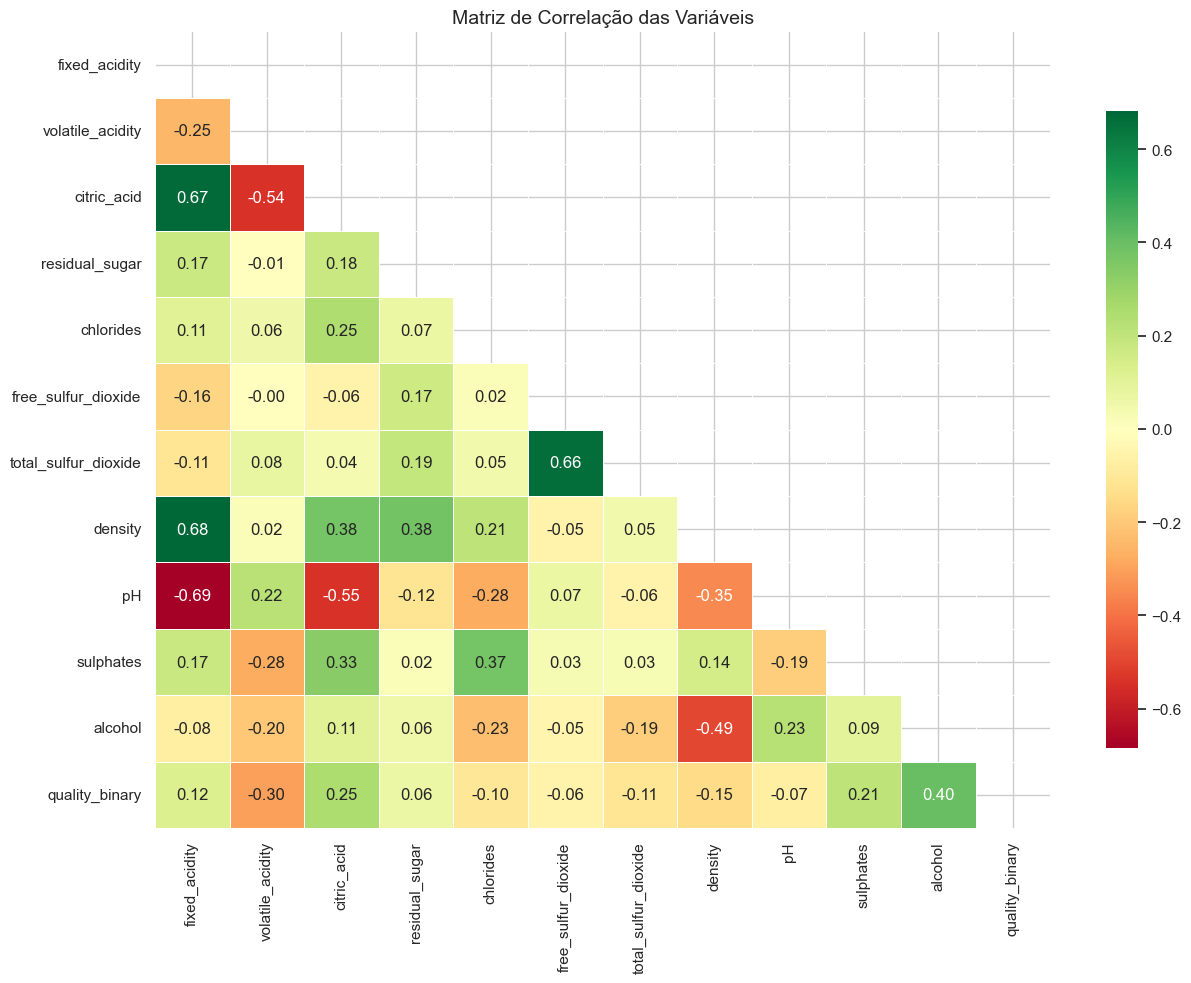


Correlação (Pearson) com quality_binary — ordenada por magnitude:
alcohol                 0.404
volatile_acidity       -0.305
citric_acid             0.251
sulphates               0.208
density                -0.149
fixed_acidity           0.123
total_sulfur_dioxide   -0.113
chlorides              -0.104
pH                     -0.073
residual_sugar          0.064
free_sulfur_dioxide    -0.056


In [9]:
# 3.5 Matriz de correlação
corr = df[num_cols + ['quality_binary']].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de Correlação das Variáveis', fontsize=14)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/04_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlação com o target: mantém o SINAL (direção) e ordena pela magnitude
target_corr_signed = (corr['quality_binary'].drop('quality_binary')
                          .sort_values(key=abs, ascending=False))
target_corr = target_corr_signed.abs()  # usada adiante para ranquear as variáveis

print('\nCorrelação (Pearson) com quality_binary — ordenada por magnitude:')
print(target_corr_signed.round(3).to_string())

### 3.5.1 Justificativa das correlações

A correlação de Pearson mede apenas associação **linear**, então os valores abaixo são o ponto de
partida da investigação — não uma prova de causalidade. A leitura de cada uma, à luz da enologia:

| Variável | Corr. com alta qualidade | Interpretação |
|---|---|---|
| **alcohol** | **+0,40** (a mais forte) | O álcool vem da fermentação dos açúcares da uva. Uvas mais maduras e concentradas geram mais açúcar e, portanto, mais álcool — o teor alcoólico funciona como um *proxy* da qualidade da matéria-prima, e não como causa direta da nota. |
| **volatile_acidity** | **−0,31** | Acidez volátil é essencialmente ácido acético: em excesso, dá ao vinho aroma e sabor de vinagre. É o defeito sensorial clássico do tinto, e a associação negativa forte era esperada. |
| **citric_acid** | **+0,25** | Contribui com frescor e sensação cítrica, além de realçar a estrutura. Boa parte do seu efeito, porém, é indireta: correlaciona-se fortemente com a acidez fixa e **negativamente** com a acidez volátil — ou seja, vinhos com mais ácido cítrico tendem a ser vinhos com menos defeito. |
| **sulphates** | **+0,21** | Atuam como antimicrobianos e antioxidantes, protegendo o vinho da oxidação e da deterioração. Em dose adequada, preservam os aromas — daí a associação positiva. |
| **density** | **−0,15** | Em boa parte, o espelho do álcool: o etanol é menos denso que a água, então mais álcool implica menor densidade. **Não é um efeito independente.** |
| **fixed_acidity** | **+0,12** | Acidez tartárica, base estrutural do vinho. Efeito fraco e largamente sobreposto ao do ácido cítrico. |
| **total_sulfur_dioxide** | **−0,11** | SO₂ total em excesso deixa cheiro sulfuroso e sensação de "vinho de garrafão". O sinal negativo é coerente, mas fraco. |
| **chlorides** | **−0,10** | Teor de sal. Excesso denuncia terroir salino ou falha de vinificação e traz sabor salgado indesejado. |
| **pH, residual_sugar, free_sulfur_dioxide** | ≤ 0,07 | Sem associação linear apreciável com o alvo binário. Não devem ser descartadas por isso: modelos não-lineares como a Random Forest ainda podem extrair valor delas em combinação com outras variáveis. |

**Três ressalvas importantes desta análise:**

1. **Multicolinearidade.** `alcohol` e `density` carregam em boa medida a mesma informação, assim como
   `fixed_acidity`, `citric_acid` e `pH` (os três descrevem a mesma dimensão de acidez). Isso não
   prejudica a Random Forest, mas infla e desestabiliza os coeficientes da Regressão Logística — motivo
   pelo qual o modelo linear deve ser lido com cautela na seção de interpretação.
2. **Correlação não é efeito isolado.** O ácido cítrico ilustra bem: sua associação positiva com a nota
   convive com uma correlação negativa forte com a acidez volátil. Parte do "mérito" do cítrico é, na
   verdade, a **ausência do defeito** do acético.
3. **Escopo da base.** Este dataset contém **apenas vinhos tintos** (1.143 amostras). As conclusões não
   podem ser estendidas a vinhos brancos sem nova validação: o perfil físico-químico dos brancos é
   bastante diferente, sobretudo em SO₂, açúcar residual e acidez volátil.

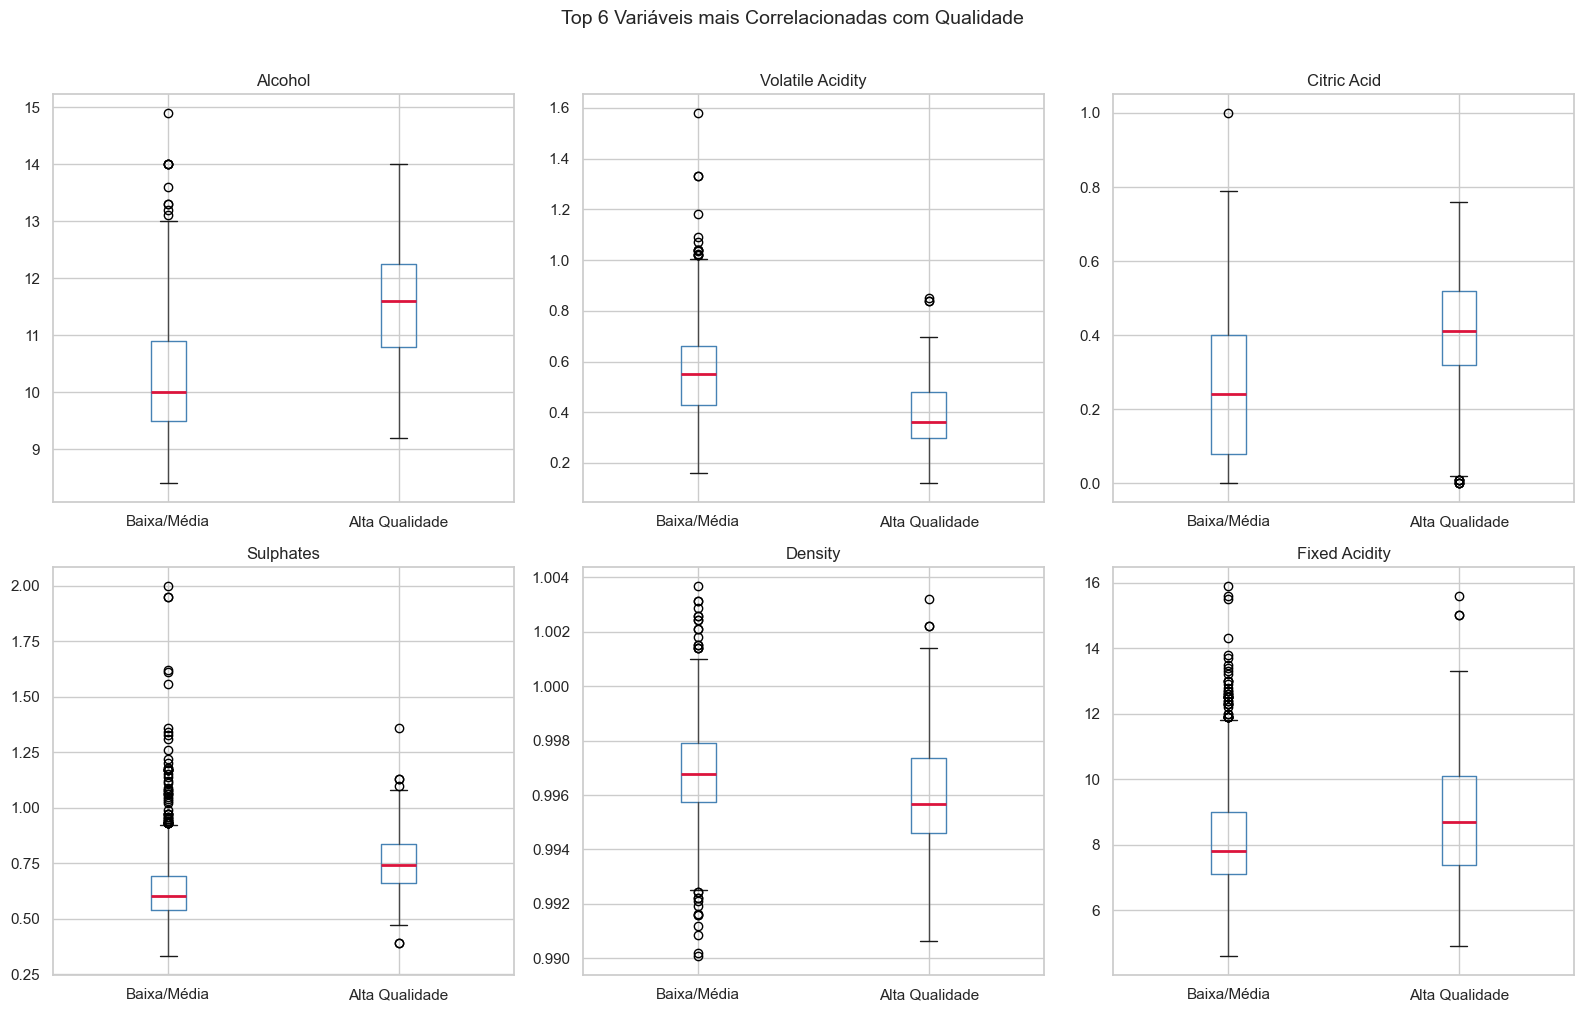

In [10]:
# 3.6 Boxplots - variáveis mais correlacionadas
top_features = target_corr.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(top_features):
    df.boxplot(column=col, by='quality_binary', ax=axes[i],
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='crimson', linewidth=2))
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=12)
    axes[i].set_xlabel('Classe (0=Baixa/Média | 1=Alta)')
    axes[i].set_xlabel('')
    plt.sca(axes[i])
    plt.xticks([1, 2], ['Baixa/Média', 'Alta Qualidade'])

plt.suptitle('Top 6 Variáveis mais Correlacionadas com Qualidade', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/05_boxplots_top_features.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# 3.7 Detecção de outliers com IQR
outlier_summary = []
for col in num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    outlier_summary.append({'variável': col, 'outliers': outliers, 'pct': f"{outliers/len(df)*100:.1f}%"})

pd.DataFrame(outlier_summary).set_index('variável')

,outliers,pct
variável,,
fixed_acidity,44,3.8%
volatile_acidity,14,1.2%
citric_acid,1,0.1%
residual_sugar,110,9.6%
chlorides,77,6.7%
free_sulfur_dioxide,18,1.6%
total_sulfur_dioxide,40,3.5%
density,36,3.1%
pH,20,1.7%


**Decisão sobre os outliers:** nenhuma variável apresenta valores fisicamente impossíveis (negativos, pH fora da
faixa 2,7–4,0 etc.), portanto não há *valores inconsistentes* a corrigir. Os pontos sinalizados pelo critério IQR
são caudas legítimas da distribuição — vinhos genuinamente muito doces, muito ácidos ou muito sulfurados existem, e
alguns deles são justamente os de alta qualidade que o modelo precisa aprender a reconhecer. **Por isso optamos por
mantê-los**, e não por remover ou winsorizar: descartá-los eliminaria parte da classe minoritária, que já é escassa.
A Random Forest é robusta a outliers por construção; na Regressão Logística, o `StandardScaler` limita o estrago.

---
## 4. Pré-processamento

In [12]:
# 4.1 Feature Engineering
# Novas features com base no conhecimento de domínio
df['acid_ratio']      = df['fixed_acidity'] / (df['volatile_acidity'] + 1e-6)
df['sulfur_ratio']    = df['free_sulfur_dioxide'] / (df['total_sulfur_dioxide'] + 1e-6)
df['alcohol_density'] = df['alcohol'] / df['density']

print('✅ Novas features criadas:')
print('  acid_ratio:      Razão entre acidez fixa e volátil (equilíbrio x defeito)')
print('  sulfur_ratio:    Proporção de SO₂ livre no total (parcela ainda ativa como conservante)')
print('  alcohol_density: Relação álcool/densidade (proxy para o corpo do vinho)')
print()
print('Obs.: não há feature de tipo de vinho — a base contém apenas tintos.')

✅ Novas features criadas:
  acid_ratio:      Razão entre acidez fixa e volátil (equilíbrio x defeito)
  sulfur_ratio:    Proporção de SO₂ livre no total (parcela ainda ativa como conservante)
  alcohol_density: Relação álcool/densidade (proxy para o corpo do vinho)

Obs.: não há feature de tipo de vinho — a base contém apenas tintos.


In [13]:
# 4.2 Separação features / target / split
FEATURE_COLS = num_cols + ['acid_ratio', 'sulfur_ratio', 'alcohol_density']
TARGET_COL   = 'quality_binary'

X = df[FEATURE_COLS]
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'Features: {len(FEATURE_COLS)}')
print(f'Treino: {X_train.shape[0]} amostras  |  Teste: {X_test.shape[0]} amostras')
print(f'\nDistribuição no treino:\n{y_train.value_counts(normalize=True).round(3)}')
print(f'\nDistribuição no teste:\n{y_test.value_counts(normalize=True).round(3)}')

Features: 14
Treino: 914 amostras  |  Teste: 229 amostras

Distribuição no treino:
quality_binary
0    0.861
1    0.139
Name: proportion, dtype: float64

Distribuição no teste:
quality_binary
0    0.86
1    0.14
Name: proportion, dtype: float64


---
## 5. Desenvolvimento dos Modelos

In [14]:
# 5.1 Pipelines (preprocessamento + modelo)
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced'))
])

pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  RandomForestClassifier(n_estimators=200, max_depth=15,
                                       random_state=SEED, class_weight='balanced', n_jobs=-1))
])

# 5.2 Treinamento
pipeline_lr.fit(X_train, y_train)
pipeline_rf.fit(X_train, y_train)

print('✅ Modelos treinados!')

✅ Modelos treinados!


In [15]:
# 5.3 Cross-Validation (5-fold, estratificado)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for name, pipe in [('Logistic Regression', pipeline_lr), ('Random Forest', pipeline_rf)]:
    scores_f1  = cross_val_score(pipe, X, y, cv=cv, scoring='f1')
    scores_roc = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc')
    print(f'{name}:')
    print(f'  F1-Score: {scores_f1.mean():.4f} ± {scores_f1.std():.4f}')
    print(f'  ROC-AUC:  {scores_roc.mean():.4f} ± {scores_roc.std():.4f}')
    print()

Logistic Regression:
  F1-Score: 0.5010 ± 0.0281
  ROC-AUC:  0.8748 ± 0.0290



Random Forest:
  F1-Score: 0.6362 ± 0.0989
  ROC-AUC:  0.9327 ± 0.0323



---
## 6. Avaliação dos Modelos

In [16]:
# 6.1 Predições
y_pred_lr = pipeline_lr.predict(X_test)
y_pred_rf = pipeline_rf.predict(X_test)
y_prob_lr = pipeline_lr.predict_proba(X_test)[:, 1]
y_prob_rf = pipeline_rf.predict_proba(X_test)[:, 1]

# 6.2 Métricas comparativas
metrics_data = []
for name, y_pred, y_prob in [
    ('Logistic Regression', y_pred_lr, y_prob_lr),
    ('Random Forest',       y_pred_rf, y_prob_rf)
]:
    metrics_data.append({
        'Modelo':     name,
        'Accuracy':   accuracy_score(y_test, y_pred),
        'Precision':  precision_score(y_test, y_pred),
        'Recall':     recall_score(y_test, y_pred),
        'F1-Score':   f1_score(y_test, y_pred),
        'ROC-AUC':    roc_auc_score(y_test, y_prob)
    })

df_metrics = pd.DataFrame(metrics_data).set_index('Modelo').round(4)
print('=== COMPARAÇÃO DE MÉTRICAS ===')
df_metrics

=== COMPARAÇÃO DE MÉTRICAS ===


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Modelo,,,,,
Logistic Regression,0.7904,0.3621,0.6562,0.4667,0.8637
Random Forest,0.9214,0.8182,0.5625,0.6667,0.9118


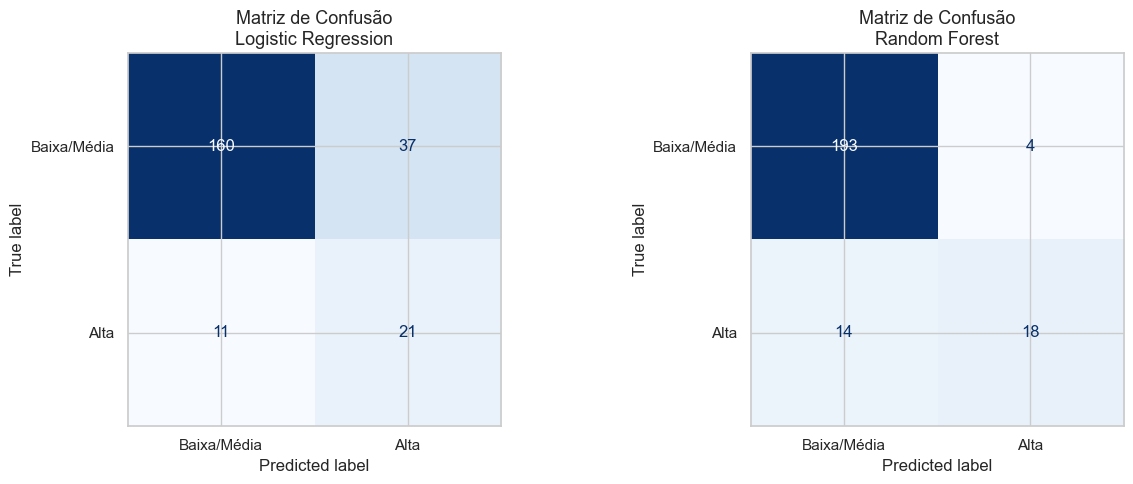

In [17]:
# 6.3 Matrizes de confusão
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, name, y_pred in [
    (axes[0], 'Logistic Regression', y_pred_lr),
    (axes[1], 'Random Forest',       y_pred_rf)
]:
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Baixa/Média', 'Alta'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Matriz de Confusão\n{name}', fontsize=13)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/06_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

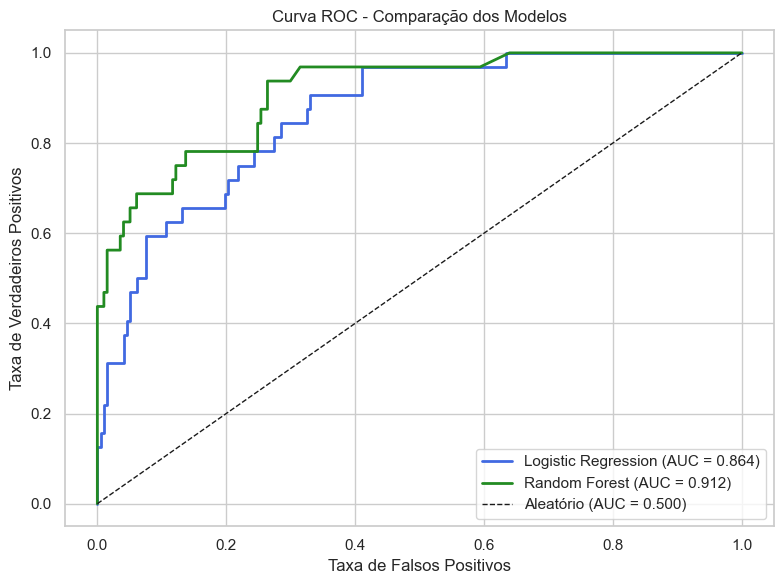

In [18]:
# 6.4 Curvas ROC
fig, ax = plt.subplots(figsize=(8, 6))

for name, y_prob, color in [
    ('Logistic Regression', y_prob_lr, 'royalblue'),
    ('Random Forest',       y_prob_rf, 'forestgreen')
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=color, lw=2)

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatório (AUC = 0.500)')
ax.set_xlabel('Taxa de Falsos Positivos')
ax.set_ylabel('Taxa de Verdadeiros Positivos')
ax.set_title('Curva ROC - Comparação dos Modelos')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/07_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# 6.5 Relatório completo
for name, y_pred in [('Logistic Regression', y_pred_lr), ('Random Forest', y_pred_rf)]:
    print(f'=== {name} ===')
    print(classification_report(y_test, y_pred, target_names=['Baixa/Média', 'Alta Qualidade']))
    print()

=== Logistic Regression ===
                precision    recall  f1-score   support

   Baixa/Média       0.94      0.81      0.87       197
Alta Qualidade       0.36      0.66      0.47        32

      accuracy                           0.79       229
     macro avg       0.65      0.73      0.67       229
  weighted avg       0.86      0.79      0.81       229


=== Random Forest ===
                precision    recall  f1-score   support

   Baixa/Média       0.93      0.98      0.96       197
Alta Qualidade       0.82      0.56      0.67        32

      accuracy                           0.92       229
     macro avg       0.88      0.77      0.81       229
  weighted avg       0.92      0.92      0.92       229




---
## 7. Interpretação dos Resultados

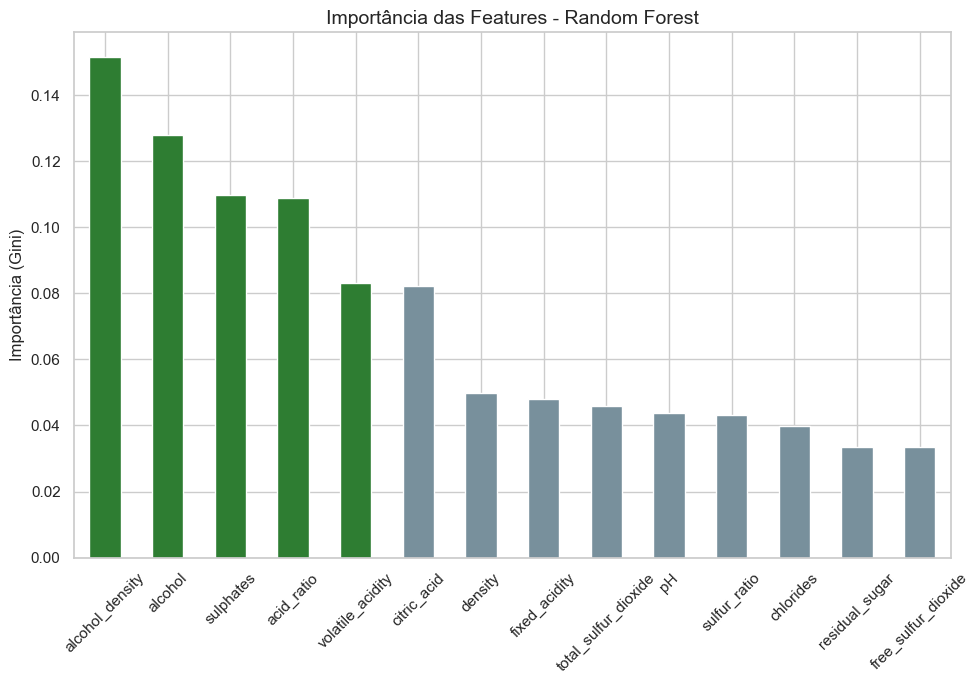

Top 5 variáveis mais importantes (Random Forest):
alcohol_density     0.1514
alcohol             0.1279
sulphates           0.1097
acid_ratio          0.1087
volatile_acidity    0.0830


In [20]:
# 7.1 Importância das features - Random Forest
rf_model = pipeline_rf.named_steps['model']
importances = pd.Series(rf_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#2E7D32' if i < 5 else '#78909C' for i in range(len(importances))]
importances.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.set_title('Importância das Features - Random Forest', fontsize=14)
ax.set_ylabel('Importância (Gini)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/08_feature_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 variáveis mais importantes (Random Forest):')
print(importances.head(5).round(4).to_string())

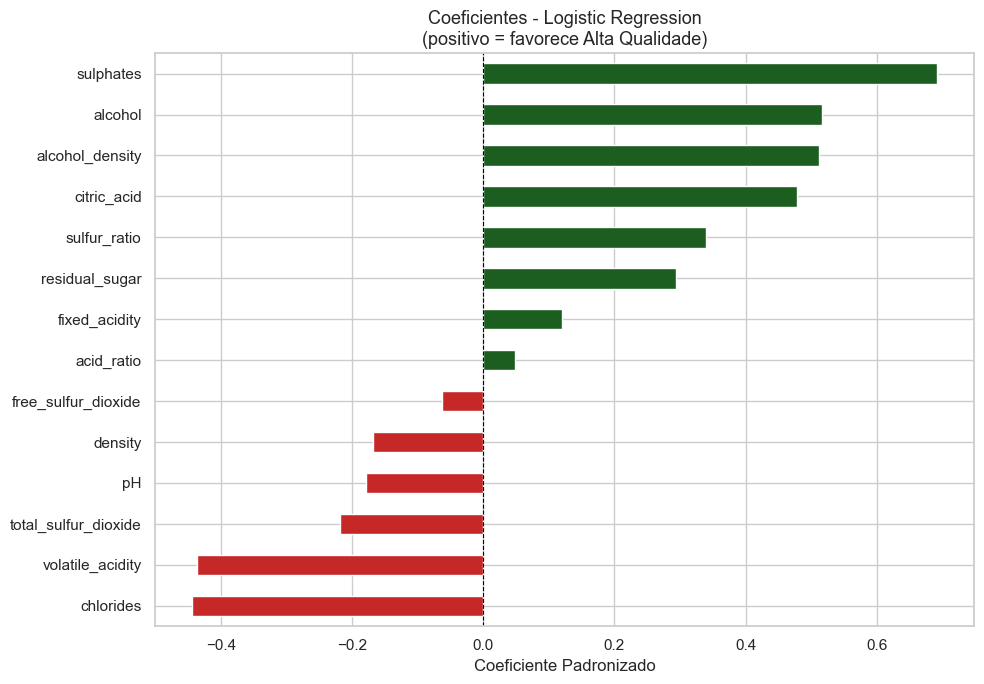

In [21]:
# 7.2 Importância das features - Logistic Regression (coeficientes padronizados)
lr_model = pipeline_lr.named_steps['model']
coef = pd.Series(lr_model.coef_[0], index=FEATURE_COLS).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#C62828' if c < 0 else '#1B5E20' for c in coef]
coef.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Coeficientes - Logistic Regression\n(positivo = favorece Alta Qualidade)', fontsize=13)
ax.set_xlabel('Coeficiente Padronizado')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/09_feature_importance_lr.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# 7.3 Resumo executivo dos resultados
print('=' * 68)
print('          RESUMO EXECUTIVO - RESULTADOS FINAIS')
print('=' * 68)
print()
print(f'BASE: {len(df)} amostras de vinho tinto (Wine Quality Dataset / Kaggle)')
print()
print('DESEMPENHO NO CONJUNTO DE TESTE:')
print(df_metrics.to_string())
print()
best = df_metrics['ROC-AUC'].idxmax()
print(f'MELHOR MODELO: {best} (maior ROC-AUC)')
print()
print('TOP 5 VARIÁVEIS COM MAIOR INFLUÊNCIA NA QUALIDADE (Random Forest):')
for i, (feat, imp) in enumerate(importances.head(5).items(), 1):
    print(f'  {i}. {feat}: {imp:.4f}')
print()
print('IMPLICAÇÕES PARA O PROCESSO DE PRODUÇÃO:')
print('  • Teor alcoólico é o principal marcador de alta qualidade — reflete uvas')
print('    mais maduras e concentradas na colheita.')
print('  • Acidez volátil é o principal defeito: controlá-la durante a fermentação')
print('    evita o aroma avinagrado que derruba a nota.')
print('  • Sulfatos em dose adequada preservam o vinho da oxidação e acompanham')
print('    notas mais altas.')
print()
print('LIMITE DE ESCOPO: a base contém apenas vinhos tintos. Estender as conclusões')
print('a vinhos brancos exige nova validação.')
print('=' * 68)

          RESUMO EXECUTIVO - RESULTADOS FINAIS

BASE: 1143 amostras de vinho tinto (Wine Quality Dataset / Kaggle)

DESEMPENHO NO CONJUNTO DE TESTE:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Modelo                                                             
Logistic Regression    0.7904     0.3621  0.6562    0.4667   0.8637
Random Forest          0.9214     0.8182  0.5625    0.6667   0.9118

MELHOR MODELO: Random Forest (maior ROC-AUC)

TOP 5 VARIÁVEIS COM MAIOR INFLUÊNCIA NA QUALIDADE (Random Forest):
  1. alcohol_density: 0.1514
  2. alcohol: 0.1279
  3. sulphates: 0.1097
  4. acid_ratio: 0.1087
  5. volatile_acidity: 0.0830

IMPLICAÇÕES PARA O PROCESSO DE PRODUÇÃO:
  • Teor alcoólico é o principal marcador de alta qualidade — reflete uvas
    mais maduras e concentradas na colheita.
  • Acidez volátil é o principal defeito: controlá-la durante a fermentação
    evita o aroma avinagrado que derruba a nota.
  • Sulfatos em dose adequada preservam o vinho da 

In [23]:
# Salvar métricas
df_metrics.to_csv(f'{RESULTS_DIR}/metricas_modelos.csv')
print('✅ Métricas salvas em results/metricas_modelos.csv')

✅ Métricas salvas em results/metricas_modelos.csv
